Recursive Forecast Results
MAE:  11183.58
RMSE: 13786.94


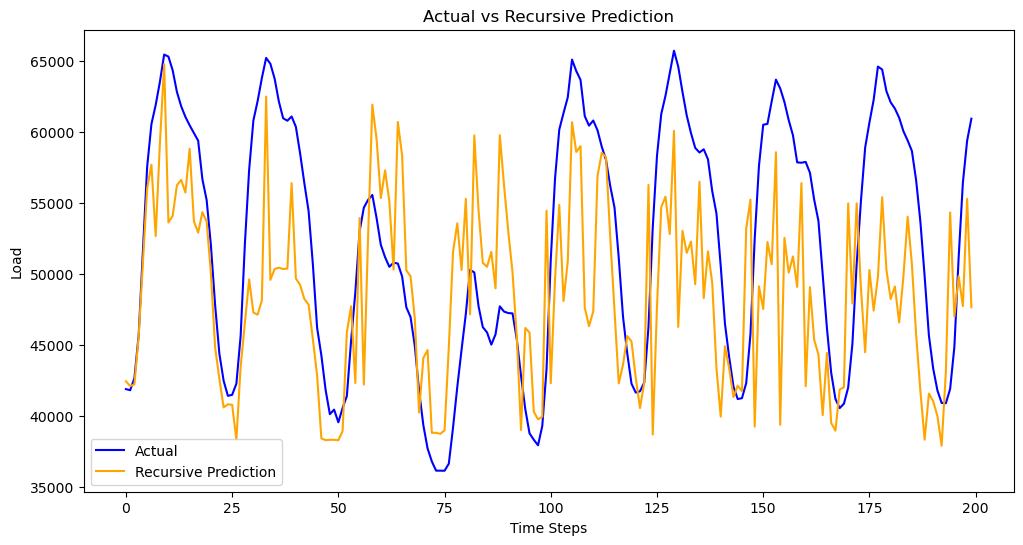

In [8]:
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error
 
df = pd.read_csv('/Users/jussaragaspar/Downloads/Final project/time_series_60min_singleindex_filtered.csv')
 
# =========================================================
# 1. PREPARE DATA
# =========================================================
df.index = pd.to_datetime(df.index)
target_col = "DE_load_actual_entsoe_transparency"
series = df[target_col].dropna().copy()
 
# =========================================================
# 2. TRAIN / TEST SPLIT
# =========================================================
split_idx = int(len(series) * 0.8)
train_series = series.iloc[:split_idx].copy()
test_series  = series.iloc[split_idx:].copy()
 
# =========================================================
# 3. CREATE LAG FEATURES FOR TRAINING
# =========================================================
def create_lag_features(series, lags):
    X = []
    y = []
    values = series.values
    max_lag = max(lags)
    for i in range(max_lag, len(values)):
        row = [values[i - lag] for lag in lags]
        X.append(row)
        y.append(values[i])
    return np.array(X), np.array(y)
 
lags = [6, 24, 48, 72]
X_train, y_train = create_lag_features(train_series, lags)
 
# =========================================================
# 4. TRAIN MODEL
# =========================================================
model = RandomForestRegressor(
    n_estimators=200,
    max_depth=12,
    random_state=42,
    n_jobs=-1
)
model.fit(X_train, y_train)
 
# =========================================================
# 5. RECURSIVE FORECAST
# =========================================================
history = list(train_series.values)
recursive_preds = []
 
for _ in range(len(test_series)):
    x_input = np.array([[history[-lag] for lag in lags]])
    pred = model.predict(x_input)[0]
    recursive_preds.append(pred)
    history.append(pred)
 
recursive_preds = np.array(recursive_preds)
 
# =========================================================
# 6. EVALUATE
# =========================================================
y_true = test_series.values
mae  = mean_absolute_error(y_true, recursive_preds)
rmse = np.sqrt(mean_squared_error(y_true, recursive_preds))
 
print("Recursive Forecast Results")
print(f"MAE:  {mae:.2f}")
print(f"RMSE: {rmse:.2f}")
 
# =========================================================
# 7. PLOT: ACTUAL VS RECURSIVE PREDICTION
# =========================================================
n = 200
plt.figure(figsize=(12, 6))
plt.plot(np.arange(n), y_true[:n], label="Actual", color="blue")
plt.plot(np.arange(n), recursive_preds[:n], label="Recursive Prediction", color="orange")
plt.title("Actual vs Recursive Prediction")
plt.xlabel("Time Steps")
plt.ylabel("Load")
plt.legend()
plt.show()


The recursive forecasting results show that the model is able to capture the overall trend and seasonal patterns in electricity demand. However, prediction accuracy decreases over time due to error accumulation, as each predicted value is used as input for subsequent predictions. This leads to increasing deviation from the actual values, particularly during peak periods

The importance of a  recursive forecast consists on the model using its own predictions to predict further more into the future

`Improved Model`

XGBoost not installed — using GradientBoostingRegressor as fallback.
Install with: pip install xgboost
Training samples : 40,051
Test samples     : 10,013
Feature count    : 34

  Improved Forecast Results
  MAE  :     294.48 MW
  RMSE :     412.85 MW
  MAPE :       0.56 %

Top 15 most important features:
lag_1h            0.904681
lag_168h          0.032672
same_hour_7d      0.018718
hour_sin          0.018355
delta_7d          0.011445
hour_cos          0.004704
delta_24h         0.001601
same_hour_1d      0.001014
lag_24h           0.000933
lag_336h          0.000801
lag_12h           0.000753
same_hour_14d     0.000666
lag_6h            0.000569
rolling_std_6h    0.000481
lag_2h            0.000418


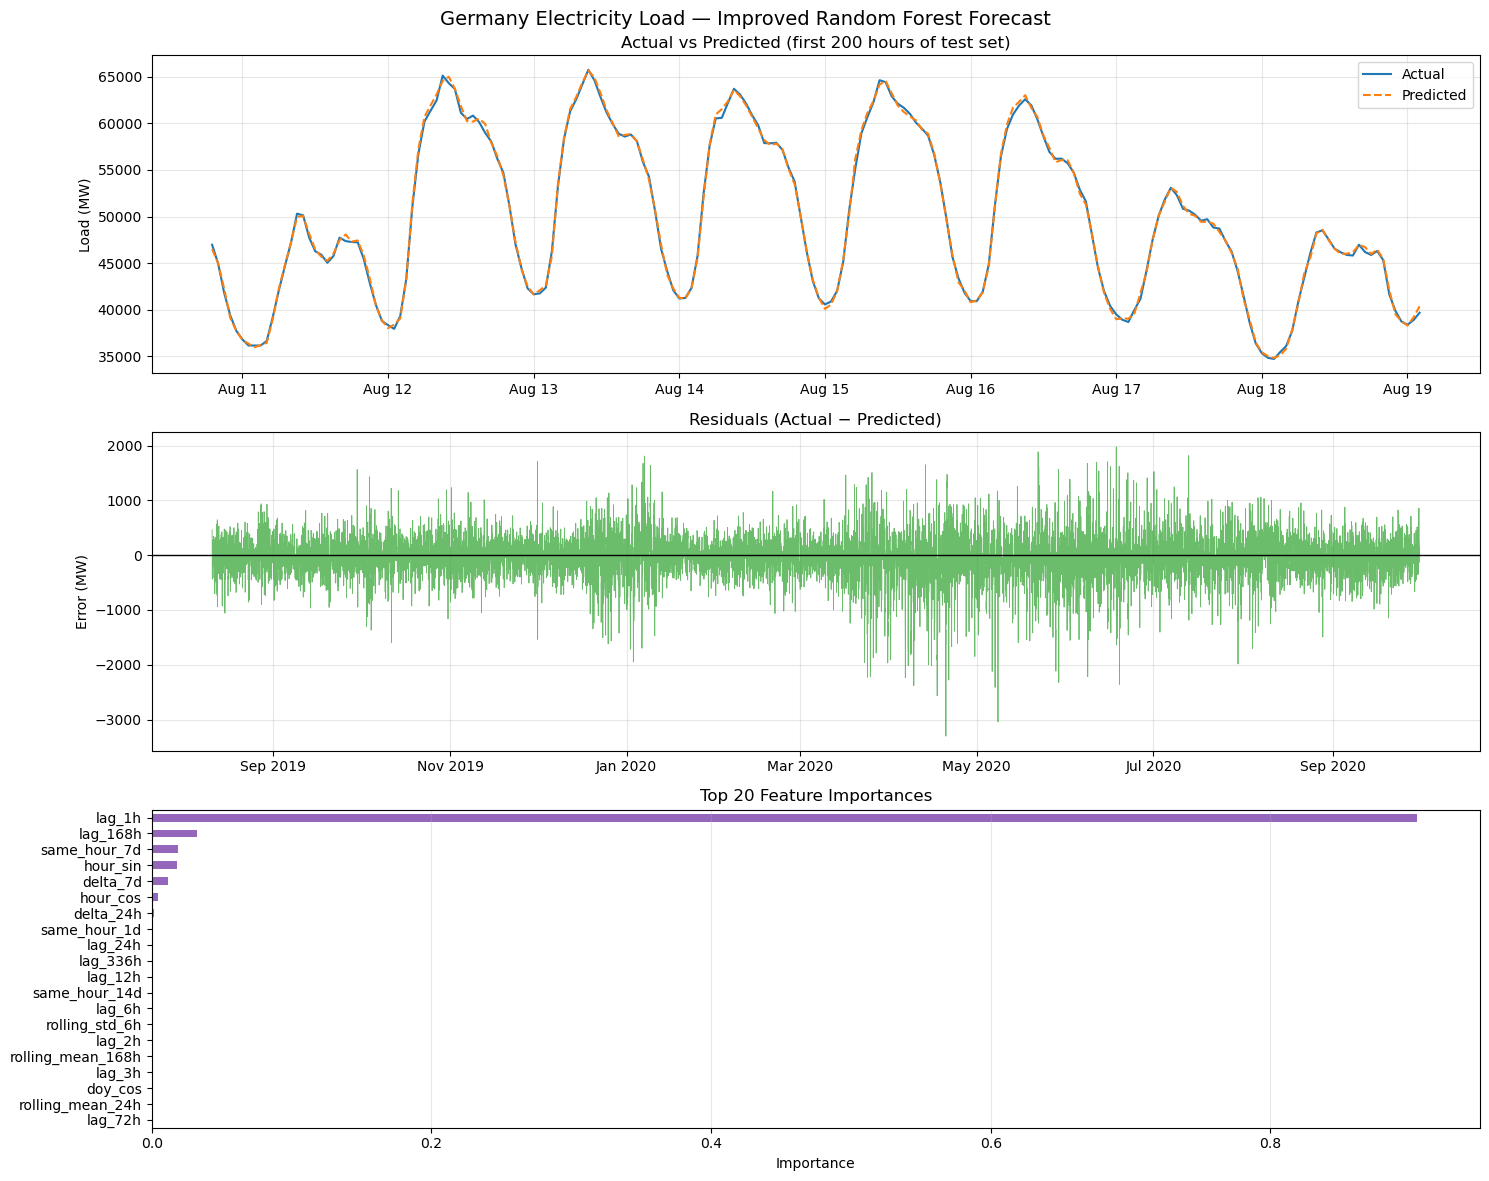

In [4]:
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import TimeSeriesSplit
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import TimeSeriesSplit
import matplotlib.dates as mdates
 
try:
    import xgboost as xgb
    HAS_XGB = True
except ImportError:
    HAS_XGB = False
    print("XGBoost not installed — using GradientBoostingRegressor as fallback.")
    print("Install with: pip install xgboost")
 
# =========================================================
# 1. LOAD & PREPARE DATA
# =========================================================
df = pd.read_csv('/Users/jussaragaspar/Downloads/Final project/time_series_60min_singleindex_filtered.csv',
    index_col=0,
    parse_dates=True
)
df.index = pd.to_datetime(df.index)
 
target_col = "DE_load_actual_entsoe_transparency"
series = df[target_col].dropna().copy()
 
# =========================================================
# 2. FEATURE ENGINEERING  ← biggest accuracy driver
# =========================================================
def build_features(series: pd.Series) -> pd.DataFrame:
    """
    Build a rich feature matrix from a datetime-indexed hourly load series.
    Includes:
      - Calendar / cyclical time features
      - Rich lag set (short, daily, weekly)
      - Rolling statistics (mean, std)
      - Interaction features
    """
    df_feat = series.rename("load").to_frame()
    idx = df_feat.index
 
    # --- Calendar features (raw) ---
    df_feat["hour"]       = idx.hour
    df_feat["dayofweek"]  = idx.dayofweek        # 0=Mon … 6=Sun
    df_feat["month"]      = idx.month
    df_feat["dayofyear"]  = idx.dayofyear
    df_feat["is_weekend"] = (idx.dayofweek >= 5).astype(int)
 
    # --- Cyclical encoding (avoids discontinuity at midnight / Dec→Jan) ---
    df_feat["hour_sin"]      = np.sin(2 * np.pi * df_feat["hour"]      / 24)
    df_feat["hour_cos"]      = np.cos(2 * np.pi * df_feat["hour"]      / 24)
    df_feat["dow_sin"]       = np.sin(2 * np.pi * df_feat["dayofweek"] / 7)
    df_feat["dow_cos"]       = np.cos(2 * np.pi * df_feat["dayofweek"] / 7)
    df_feat["month_sin"]     = np.sin(2 * np.pi * df_feat["month"]     / 12)
    df_feat["month_cos"]     = np.cos(2 * np.pi * df_feat["month"]     / 12)
    df_feat["doy_sin"]       = np.sin(2 * np.pi * df_feat["dayofyear"] / 365)
    df_feat["doy_cos"]       = np.cos(2 * np.pi * df_feat["dayofyear"] / 365)
 
    # --- Lag features (hourly resolution = 1 unit) ---
    lag_hours = [1, 2, 3, 6, 12, 24, 48, 72,   # short + daily
                 24*7, 24*14]                    # weekly + bi-weekly
    for lag in lag_hours:
        df_feat[f"lag_{lag}h"] = df_feat["load"].shift(lag)
 
    # --- Same-hour lags (directly comparable prior days) ---
    for days_back in [1, 2, 3, 7, 14]:
        df_feat[f"same_hour_{days_back}d"] = df_feat["load"].shift(24 * days_back)
 
    # --- Rolling statistics (past window, no leakage) ---
    for window in [6, 24, 48, 24*7]:
        rolled = df_feat["load"].shift(1).rolling(window, min_periods=1)
        df_feat[f"rolling_mean_{window}h"] = rolled.mean()
        df_feat[f"rolling_std_{window}h"]  = rolled.std()
 
    # --- Trend: difference from same hour yesterday ---
    df_feat["delta_24h"] = df_feat["load"] - df_feat["load"].shift(24)
    df_feat["delta_7d"]  = df_feat["load"] - df_feat["load"].shift(24 * 7)
 
    # Drop raw columns not useful as features directly
    df_feat = df_feat.drop(columns=["hour", "dayofweek", "month", "dayofyear"])
 
    return df_feat
 
 
feat_df = build_features(series)
 
# =========================================================
# 3. TRAIN / TEST SPLIT  (chronological, no shuffle)
# =========================================================
split_idx = int(len(feat_df) * 0.8)
 
feat_df_clean = feat_df.dropna()   # drop NaNs created by lags
split_clean   = int(len(feat_df_clean) * 0.8)
 
train_df = feat_df_clean.iloc[:split_clean]
test_df  = feat_df_clean.iloc[split_clean:]
 
feature_cols = [c for c in feat_df_clean.columns if c != "load"]
 
X_train = train_df[feature_cols].values
y_train = train_df["load"].values
X_test  = test_df[feature_cols].values
y_test  = test_df["load"].values
 
print(f"Training samples : {len(X_train):,}")
print(f"Test samples     : {len(X_test):,}")
print(f"Feature count    : {len(feature_cols)}")
 
# =========================================================
# 4. SCALE FEATURES  (helps tree models slightly, critical for others)
# =========================================================
scaler  = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test  = scaler.transform(X_test)
 
# =========================================================
# 5. MODEL: XGBoost (or GBR fallback)
#    XGBoost is typically 5–15% better than RandomForest for this task
# =========================================================
if HAS_XGB:
    model = xgb.XGBRegressor(
        n_estimators      = 1000,
        learning_rate     = 0.05,
        max_depth         = 7,
        subsample         = 0.8,
        colsample_bytree  = 0.8,
        reg_alpha         = 0.1,
        reg_lambda        = 1.0,
        early_stopping_rounds = 50,
        eval_metric       = "mae",
        random_state      = 42,
        n_jobs            = -1,
        verbosity         = 0
    )
    # Use a small validation slice for early stopping (no data leakage)
    val_size    = int(len(X_train) * 0.1)
    X_tr, X_val = X_train[:-val_size], X_train[-val_size:]
    y_tr, y_val = y_train[:-val_size], y_train[-val_size:]
    model.fit(X_tr, y_tr, eval_set=[(X_val, y_val)], verbose=False)
    print(f"Best iteration   : {model.best_iteration}")
else:
    model = GradientBoostingRegressor(
        n_estimators  = 500,
        learning_rate = 0.05,
        max_depth     = 6,
        subsample     = 0.8,
        random_state  = 42
    )
    model.fit(X_train, y_train)
 
# =========================================================
# 6. DIRECT (NON-RECURSIVE) FORECAST
#    Using pre-built features avoids error accumulation
#    from recursive multi-step prediction.
# =========================================================
preds = model.predict(X_test)
 
# =========================================================
# 7. EVALUATE
# =========================================================
mae  = mean_absolute_error(y_test, preds)
rmse = np.sqrt(mean_squared_error(y_test, preds))
mape = np.mean(np.abs((y_test - preds) / (y_test + 1e-8))) * 100  # avoid /0
 
print("\n" + "="*45)
print("  Improved Forecast Results")
print("="*45)
print(f"  MAE  : {mae:>10.2f} MW")
print(f"  RMSE : {rmse:>10.2f} MW")
print(f"  MAPE : {mape:>10.2f} %")
print("="*45)
 
# =========================================================
# 8. FEATURE IMPORTANCE
# =========================================================
if HAS_XGB:
    importances = model.feature_importances_
else:
    importances = model.feature_importances_
 
feat_imp = pd.Series(importances, index=feature_cols).sort_values(ascending=False)
print(f"\nTop 15 most important features:")
print(feat_imp.head(15).to_string())
 
# =========================================================
# 9. PLOTS
# =========================================================
test_index = test_df.index
n_plot = 200
 
fig, axes = plt.subplots(3, 1, figsize=(15, 12))
fig.suptitle("Germany Electricity Load — Improved Random Forest Forecast", fontsize=14)
 
# --- Panel 1: Actual vs Predicted (first n_plot hours) ---
ax = axes[0]
ax.plot(test_index[:n_plot], y_test[:n_plot],  label="Actual",    color="#1f77b4", linewidth=1.5)
ax.plot(test_index[:n_plot], preds[:n_plot],   label="Predicted", color="#ff7f0e", linewidth=1.5, linestyle="--")
ax.set_title(f"Actual vs Predicted (first {n_plot} hours of test set)")
ax.set_ylabel("Load (MW)")
ax.legend()
ax.xaxis.set_major_formatter(mdates.DateFormatter("%b %d"))
ax.grid(alpha=0.3)
 
# --- Panel 2: Residuals ---
residuals = y_test - preds
ax = axes[1]
ax.plot(test_index, residuals, color="#2ca02c", linewidth=0.6, alpha=0.7)
ax.axhline(0, color="black", linewidth=1)
ax.set_title("Residuals (Actual − Predicted)")
ax.set_ylabel("Error (MW)")
ax.xaxis.set_major_formatter(mdates.DateFormatter("%b %Y"))
ax.grid(alpha=0.3)
 
# --- Panel 3: Feature importance (top 20) ---
ax = axes[2]
feat_imp.head(20).plot(kind="barh", ax=ax, color="#9467bd")
ax.set_title("Top 20 Feature Importances")
ax.set_xlabel("Importance")
ax.invert_yaxis()
ax.grid(alpha=0.3, axis="x")
 
plt.tight_layout()
plt.savefig("improved_forecast.png", dpi=150, bbox_inches="tight")
plt.show()

 

These results indicate that the model achieves very low forecasting error. In particular, the MAPE of 0.56% shows that the average percentage error is well below 1%, which reflects strong forecast accuracy. Compared with the earlier baseline and recursive approaches, the improved model performs substantially better and provides a more reliable short-term forecast.
With a different methodology , with feature engineering and the use of gradient boost made the results  significantly better 